In [135]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
M = np.array(Image.open("thohong.jpg").convert("L"), dtype=float) 
print(M.shape)

(736, 736)


BÀI 1: BIỂU DIỄN DỮ LIỆU THÀNH MA TRẬN & ĐỘ TƯƠNG ĐỒNG

1.1. Biến đổi dữ liệu thành ma trận: Cắt ảnh thành 9 ảnh nhỏ (3x3)

In [136]:
H_full, W_full= M.shape
H = H_full // 3
W = W_full // 3
N=9

patches=[]
for i in range(3):
    for j in range(3):
        patch = M[i*H:(i+1)*H, j*W:(j+1)*W]
        patches.append(patch.flatten())

for patch in patches:
    print(patch)
X = np.array(patches)
print(X.shape)

[202. 202. 202. ... 216. 216. 216.]
[202. 202. 202. ...   4.   4.  18.]
[202. 202. 202. ... 216. 216. 216.]
[216. 216. 216. ... 190. 190. 195.]
[216. 216. 216. ... 213. 149.  25.]
[  4.  14.  12. ...  89.  99. 104.]
[233. 233. 233. ... 214. 214. 214.]
[198. 156.  35. ... 214. 213. 213.]
[ 32.   3.  12. ... 100. 100. 100.]
(9, 60025)


In [137]:
X

array([[202., 202., 202., ..., 216., 216., 216.],
       [202., 202., 202., ...,   4.,   4.,  18.],
       [202., 202., 202., ..., 216., 216., 216.],
       ...,
       [233., 233., 233., ..., 214., 214., 214.],
       [198., 156.,  35., ..., 214., 213., 213.],
       [ 32.,   3.,  12., ..., 100., 100., 100.]], shape=(9, 60025))

- Mỗi hàng đại diện cho một ảnh nhỏ cắt ra từ ảnh gốc( cắt theo thứ tự từ trái qua phải, từ trên xuống dưới)
- Mỗi cột đại diện cho pixel tại một điểm cụ thể trong mỗi bức ảnh

1.2. Phép toán cơ bản

In [138]:
column_means = np.mean(X, axis=0)
print("Vector trung binh theo cot: ", column_means)
print(column_means.shape)
print(X.shape)

Vector trung binh theo cot:  [167.22222222 160.44444444 147.77777778 ... 161.77777778 155.66666667
 144.55555556]
(60025,)
(9, 60025)


In [139]:
X_centered = X - column_means
print(X_centered.shape)

(9, 60025)


Nhờ cơ chế broadcasting mà có thể thực hiện phép trừ giữa X và column_means dù chúng khác kích thước

1.3. Cosine similarity

In [140]:
def cosine_similarity(X, Y=None):
    if Y is None:
        Y = X
    Xn = X / np.linalg.norm(X, axis=1, keepdims=True)
    Yn = Y / np.linalg.norm(Y, axis=1, keepdims=True)
    return Xn @ Yn.T


1.4. Truy vấn:

In [141]:
def search(query, top_k=3):
    if query.ndim == 1:
        query = query.reshape(1,-1)
    scores = cosine_similarity(X, query).flatten()
    top_indices = np.argsort(scores)[::-1][:top_k]
    top_scores = scores[top_indices]
    return top_indices, top_scores

1.5 Nhận xét

Tìm cặp giống, kháu nhau nhất

In [142]:
best_score = -1
best_pair = None

worst_score = 1
worst_pair = None

for i in range(N):
    indices, scores = search(X[i], top_k=N)
    similar_idx = indices[1]
    similar_score = scores[1]
    if(similar_score > best_score and i < similar_idx):
        best_score = similar_score
        best_pair = (i, similar_idx)

    dissimilar_idx = indices[8]
    dissimilar_score = scores[8]
    if(dissimilar_score < worst_score and i<dissimilar_idx):
        worst_score = dissimilar_score 
        worst_pair = (i, dissimilar_idx)

print(f"Cặp {best_pair[0]+1} và {best_pair[1]+1} giống nhau nhất(Điểm tương đồng:{best_score})")
print(f"Cặp {worst_pair[0]+1} và {worst_pair[1]+1} kháu biệt nhất(Điểm tương đồng:{worst_score})")

Cặp 1 và 3 giống nhau nhất(Điểm tương đồng:0.9926629670704625)
Cặp 7 và 9 kháu biệt nhất(Điểm tương đồng:0.8393760815710086)


Kiểm tra lại

In [143]:
X_score = cosine_similarity(X)
min_score = np.min(X_score)
min_idx = np.where(X_score == min_score)
print(f"Cặp {min_idx[0]+1} và {min_idx[1]+1} khác biệt nhất(Điểm tương đồng:{min_score})")

filtered_X_score = X_score
np.fill_diagonal(filtered_X_score,0)
max_score = np.max(filtered_X_score)
max_idx = np.where(filtered_X_score == max_score)
print(f"Cặp {max_idx[0]+1} và {max_idx[1]+1} giống nhau nhất(Điểm tương đồng:{max_score})")
print("\n")
print(X_score)

Cặp [7 9] và [9 7] khác biệt nhất(Điểm tương đồng:0.8393760815710075)
Cặp [1 3] và [3 1] giống nhau nhất(Điểm tương đồng:0.9926629670704636)


[[0.         0.96470661 0.99266297 0.97542051 0.94733049 0.93312609
  0.89817858 0.97154    0.92799149]
 [0.96470661 0.         0.96605843 0.95179934 0.92434903 0.90185504
  0.86668834 0.94555007 0.90209463]
 [0.99266297 0.96605843 0.         0.97702214 0.94761036 0.92277561
  0.89771576 0.97469539 0.92848655]
 [0.97542051 0.95179934 0.97702214 0.         0.931443   0.91901609
  0.88156992 0.96074171 0.92700221]
 [0.94733049 0.92434903 0.94761036 0.931443   0.         0.88296666
  0.86415033 0.93536931 0.88370097]
 [0.93312609 0.90185504 0.92277561 0.91901609 0.88296666 0.
  0.85674493 0.90831226 0.87710141]
 [0.89817858 0.86668834 0.89771576 0.88156992 0.86415033 0.85674493
  0.         0.89081345 0.83937608]
 [0.97154    0.94555007 0.97469539 0.96074171 0.93536931 0.90831226
  0.89081345 0.         0.91825514]
 [0.92799149 0.90209463 0.9284865

In từng ảnh đã cắt

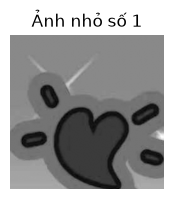

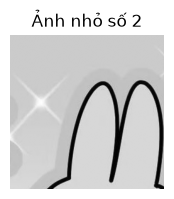

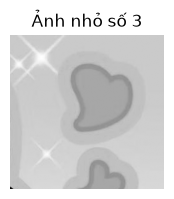

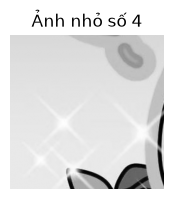

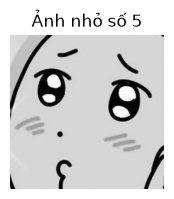

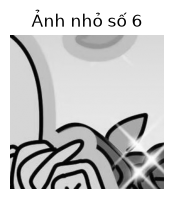

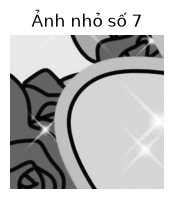

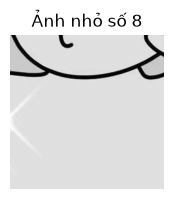

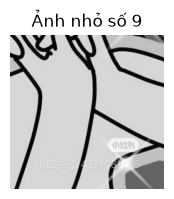

In [144]:
for i in range(9):
    image = X[i].reshape(H,W)
    plt.figure(figsize=(2,2))
    plt.imshow(image,cmap='gray')
    plt.title(f"Ảnh nhỏ số {i+1}")
    plt.axis('off')
    plt.show()

Kết quả khớp với trực giác
- Ảnh 1,3( tương đồng nhất): cùng có trái tim
- Ảnh 7, 9(tương đồng thấp nhất): không có đặc điểm nào giống nhau

BÀI 2: BIẾN ĐỔI TUYẾN TÍNH & SVD

2.1. Biến đổi tuyến tính    

Trước

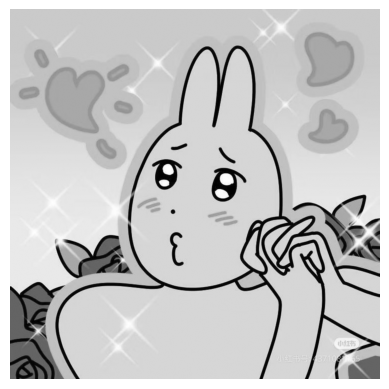

In [145]:
img = Image.open("thohong.jpg").convert("L")
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()

Sau

(np.float64(-0.5), np.float64(1039.5), np.float64(1039.5), np.float64(-0.5))

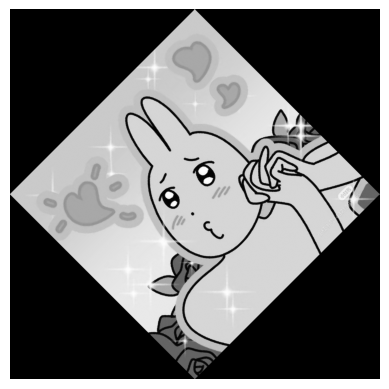

In [146]:
theta = np.radians(45)
R = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta), np.cos(theta)]])
R_inv = np.array([[np.cos(-theta), -np.sin(-theta)],
                [np.sin(-theta), np.cos(-theta)]])

xc = (H_full -1)/2.0
yc= (W_full -1)/2.0
corners = np.array([[xc,yc],
                    [-xc,yc],
                    [-xc,-yc],
                    [xc,-yc]]).T
rotated_corners = R @ corners
H_new = int(np.ceil(np.max(rotated_corners[1,:]) - np.min(rotated_corners[1,:])))
W_new = int(np.ceil(np.max(rotated_corners[0,:]) - np.min(rotated_corners[0,:])))
xc_new = (H_new - 1) / 2.0
yc_new = (W_new -1) / 2.0

i_grid, j_grid = np.meshgrid(np.arange(H_new), np.arange(W_new), indexing='ij')
X = i_grid - xc_new
Y = j_grid - yc_new

coords_new = np.vstack([X.flatten(), Y.flatten()])
coords_old = R_inv @ coords_new
x_old = coords_old[0, :] + xc
y_old = coords_old[1, :] + yc

x_round = np.round(x_old).astype(int)
y_round = np.round(y_old).astype(int)

filtered = (x_round >= 0) & (x_round < H_full) & (y_round >= 0) & (y_round <W_full)
B = np.zeros((H_new, W_new))
dest_i = i_grid.flatten()[filtered]
dest_j = j_grid.flatten()[filtered]
src_i = x_round[filtered]
src_j = y_round[filtered]

B[dest_i, dest_j]= M[src_i, src_j]
plt.imshow(B, cmap='gray')
plt.axis('off')


Zoom ảnh

(2208, 2208)


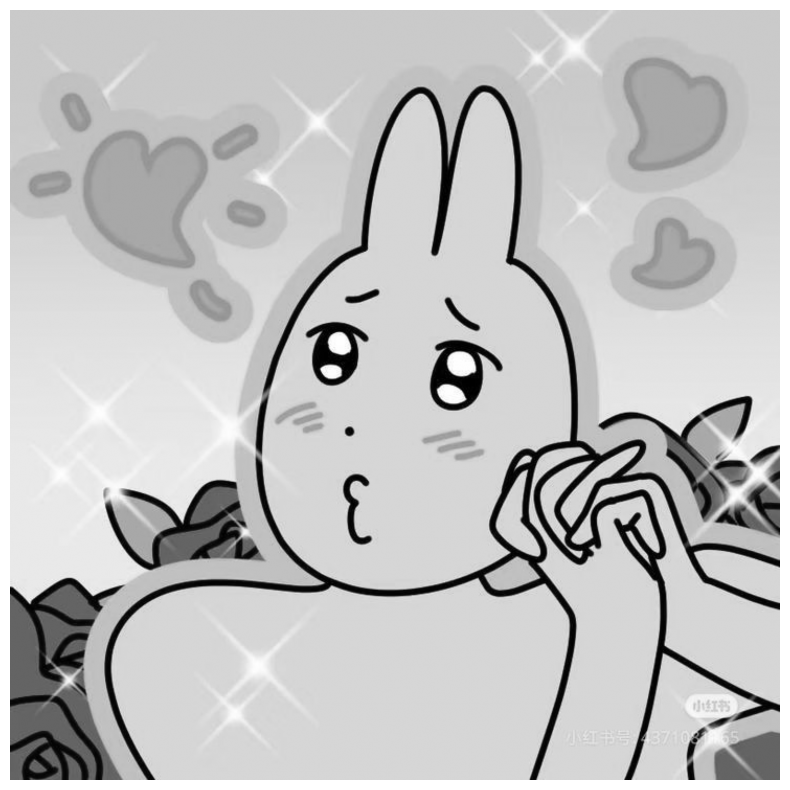

In [147]:
stretched_scale = 3
S = np.array([[stretched_scale, 0],
              [0, stretched_scale]])
S_inv = np.linalg.inv(S)

H_new1 = int(np.ceil(H_full*stretched_scale))
W_new1= int(np.ceil(W_full*stretched_scale))
xc_new1 = (H_new1 - 1) / 2.0
yc_new1 = (W_new1 -1) / 2.0

i_grid, j_grid = np.meshgrid(np.arange(H_new1), np.arange(W_new1), indexing='ij')
X1 = i_grid - xc_new1
Y1 = j_grid - yc_new1

coords_new1 = np.vstack([X1.flatten(), Y1.flatten()])
coords_old1 = S_inv @ coords_new1
x_old1 = coords_old1[0, :] + xc1
y_old1 = coords_old1[1, :] + yc1

x_round1 = np.round(x_old1).astype(int)
y_round1 = np.round(y_old1).astype(int)

filtered1 = (x_round1 >= 0) & (x_round1 < H_full) & (y_round1 >= 0) & (y_round1 <W_full)
C = np.zeros((H_new1, W_new1))
dest_i1 = i_grid.flatten()[filtered1]
dest_j1 = j_grid.flatten()[filtered1]
src_i1 = x_round1[filtered1]
src_j1 = y_round1[filtered1]

C[dest_i1, dest_j1]= M[src_i1, src_j1]
print(C.shape)
plt.figure(figsize=(10,10))
plt.imshow(C, cmap='gray')
plt.axis('off')
plt.show()

2. Nén ảnh bằng SVD

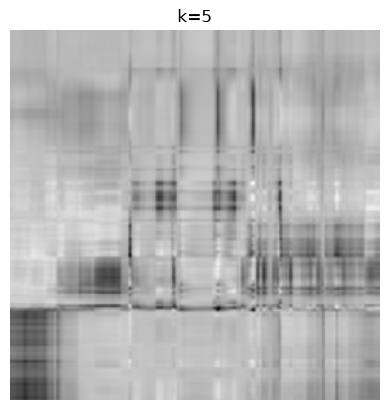

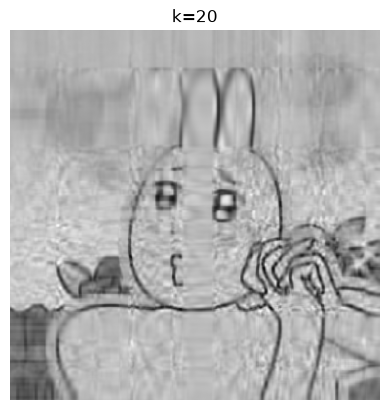

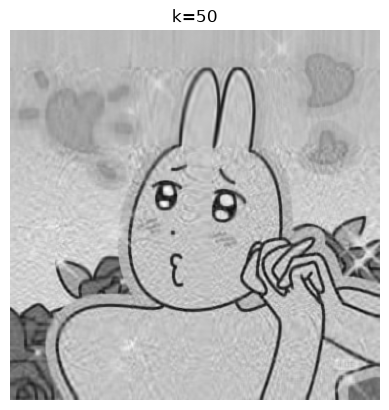

In [148]:
U, S, Vt = np.linalg.svd(M, full_matrices=False)

def reconstruct(k):
    return (U[:, :k] * S[:k]) @ Vt[:k, :]

k=[5,20,50]
for i in range(len(k)):
    plt.figure()
    M_reconstructed = reconstruct(k[i])
    plt.imshow(M_reconstructed, cmap='gray')
    plt.title(f"k={k[i]}")
    plt.axis('off')
    plt.show

2.3. Đánh giá tỉ lệ nén và sai số

k=5
Tỉ lệ nén:  0.013596186791115312
Sai số tái tạo:  1686.406365628195
k=20
Tỉ lệ nén:  0.05438474716446125
Sai số tái tạo:  756.8670822693911
k=50
Tỉ lệ nén:  0.1359618679111531
Sai số tái tạo:  234.1551985127946


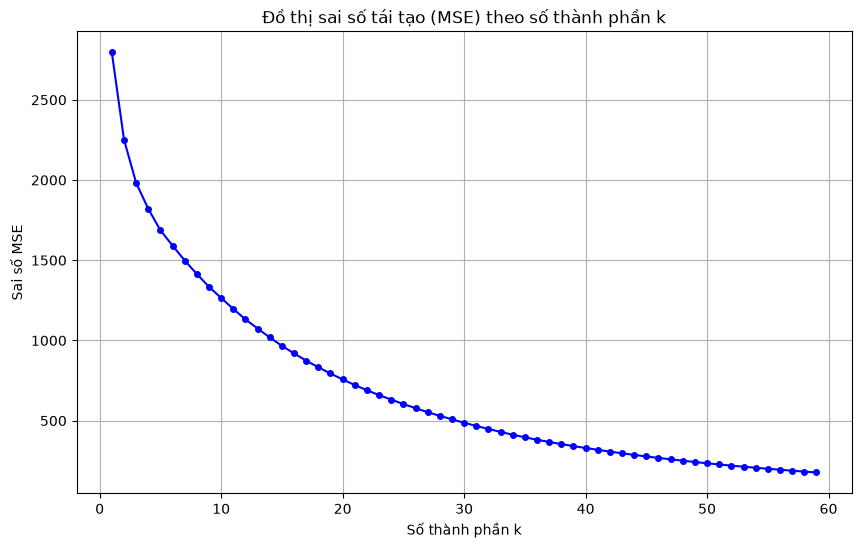

In [149]:
def compression_ratio(k,H,W):
    return (k*(H+W+1))/(H*W)

def caculate_error(k,M,H,W):
    return np.mean((M-reconstruct(k))**2)

for i in range(len(k)):
    ratio = compression_ratio(k[i],H_full,W_full)
    error = caculate_error(k[i],M,H_full,W_full)
    print(f"k={k[i]}")
    print("Tỉ lệ nén: ", ratio)
    print("Sai số tái tạo: ",error)

k_range = range(1,60)
errors = []
for k in k_range:
    error = caculate_error(k,M,H_full,W_full)
    errors.append(error)

plt.figure(figsize=(10, 6)) 
plt.plot(k_range, errors, color='blue', marker='o', linestyle='-', markersize=4)

plt.title("Đồ thị sai số tái tạo (MSE) theo số thành phần k")
plt.xlabel("Số thành phần k")
plt.ylabel("Sai số MSE")
plt.grid(True) 
plt.show()



Khi k tăng, tỉ lệ nén tăng, sai số giảm

2.4. Nhận xét

Dựa vào đồ thị, có thể thấy độ dốc của nó giảm dần k>=30. Do đó theo em, với k lớn hơn hoặc bằng 30 thì ảnh chấp nhận được

<function matplotlib.pyplot.show(close=None, block=None)>

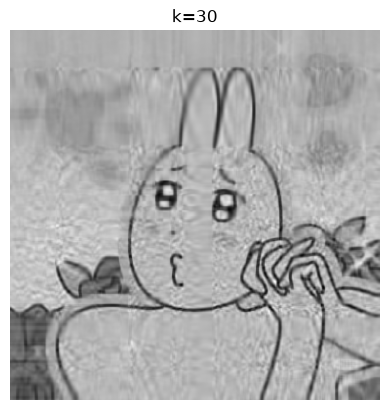

In [150]:
plt.figure()
M_reconstructed = reconstruct(30)
plt.imshow(M_reconstructed, cmap='gray')
plt.title(f"k=30")
plt.axis('off')
plt.show

- Giảm chiều dữ liệu trong AI: Giữ lại các thành phần có phương sai lớn( nhiều thông tin) và loại bỏ các chiều có phương sai nhỏ( ít thông tin, thường là nhiễu). Việc này giúp mô hình AI học những thông tin quan trọng, tổng quát, bỏ qua các nhiễu -> Mô hình sẽ tổng quát tốt hơn, tránh overfitting
- Nén dữ liệu trong AI: Mô hình sẽ chạy nhanh hơn nhiều so với ma trận đầy đủ

Bonus: vẽ đồ thị năng lượng tích lũy của các giá trị kỳ dị và chọn k giữ ≥ 90% thông tin

In [151]:
def cumulative_energy(S):
    energy = S**2
    return np.cumsum(energy)/np.sum(energy)

k_90 = np.argmax(cumulative_energy(S) >= 0.90) + 1
print(k_90)


1


Kiểm lại: In ra 10 thành phần đầu tiên của mảng chứa giá trị năng lượng tích lũy và vẽ hình

In [152]:
print(cumulative_energy(S)[:10])

[0.92860768 0.94247428 0.94936999 0.95349943 0.95692631 0.95935632
 0.96173125 0.96388983 0.9659154  0.96769147]


<function matplotlib.pyplot.show(close=None, block=None)>

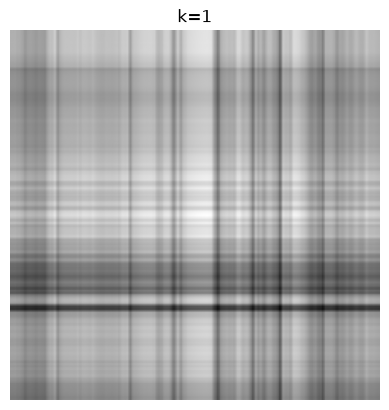

In [153]:
plt.figure()
M_reconstructed = reconstruct(1)
plt.imshow(M_reconstructed, cmap='gray')
plt.title(f"k=1")
plt.axis('off')
plt.show

- Vậy với k>=1, ảnh giữ được 90% thông tin
- Về mặt năng lượng tích lũy, thành phần kỳ dị đầu tiên đã chiếm hơn 90% giá trị. Tuy nhiên, với k=1 ảnh rất mờ và MSE cao => Với ảnh có độ phức tạp cao, các thành phần kỳ dị nhỏ có vai trò thể hiện các chi tiết, đường nét. Ví dụ với ảnh trên, k>=30 ảnh mới chấp nhận được